In [1]:

library(data.table)
library(tidyr)
library(dplyr)
library(ComplexHeatmap)
library(pheatmap)
library(circlize)
library(ggplot2)
library(OUTRIDER)
library(dplyr)
library(ggplot2)



Warning message:
“package ‘data.table’ was built under R version 4.4.2”
Warning message:
“package ‘tidyr’ was built under R version 4.4.1”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.4.1”
Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in m

In [2]:
source("~/Scripts/utils/load_gtf_cgc_dresden.R")
nrow(dresden_dt)
nrow(dresden_dt_tsg)
nrow(dresden_dt_oncogene)

[1] 141

[1] 86

[1] 32

Warning message in melt.default(cohort_with_genes, id.vars = c("Diag", "total_outlier_genes"), :
“The melt generic in data.table has been passed a tbl_df and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(cohort_with_genes). In the next version, this warning will become an error.”


pdf 
  2


 Overexpression Underexpression 
            242             297 


              ACC     Biliary_Tract              Bone             Bowel 
               14                 3                22                19 
           Breast         CNS_Brain              COAD Esophagus_Stomach 
                6                 4                 5                 9 
    Head_and_Neck               LMS              Lung             Other 
               30                 9                 5               261 
         Pancreas              Skin       Soft_Tissue              SYNS 
               10                 4               134                 4 


 Overexpression Underexpression 
            418             407 

hgncSymbol,geneID,sampleID,pValue,padjust,zScore,l2fc,rawcounts,meanRawcounts,normcounts,meanCorrected,theta,aberrant,AberrantBySample,AberrantByGene,padj_rank,foldChange,Diag,predosposition_gene,expression_direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
SEC23B,ENSG00000101310.10,ULBZNM,8.321807e-13,1.500554e-07,-8.81,-5.51,105,7959.73,136.72,6285.43,9.44,TRUE,1,1,1.0,0.02,ACC,FALSE,Underexpression
SMAD4,ENSG00000141646.9,JP81U8,1.042572e-11,1.879924e-06,-7.99,-3.27,279,5053.19,410.18,3957.62,17.64,TRUE,8,1,1.0,0.10,ACC,TRUE,Underexpression
TSC1,ENSG00000165699.9,J11M7D,3.416295e-11,6.160122e-06,-7.81,-3.33,447,4201.10,287.58,2885.50,16.23,TRUE,4,1,1.0,0.10,ACC,TRUE,Underexpression
MEN1,ENSG00000133895.10,MQ3B2C,2.345066e-10,2.114263e-05,-7.76,-4.12,36,4037.34,166.33,2971.09,11.56,TRUE,8,1,2.0,0.06,ACC,TRUE,Underexpression
SDHB,ENSG00000117118.5,NBLW1GU,2.392048e-10,2.156621e-05,-7.49,-3.00,657,7251.82,767.44,6133.25,17.28,TRUE,9,1,2.0,0.12,ACC,TRUE,Underexpression
NRAS,ENSG00000213281.4,ZN1T1D,1.516812e-09,1.367527e-04,-7.11,-2.76,1214,4188.70,495.91,3355.17,17.82,TRUE,4,1,2.0,0.15,ACC,TRUE,Underexpression
TRIM37,ENSG00000108395.9,V8TWUJ,8.532054e-10,1.538465e-04,-7.32,-2.92,303,2745.85,264.01,2004.94,17.04,TRUE,1,1,1.0,0.13,ACC,TRUE,Underexpression
AKT2,ENSG00000105221.12,C7517E,3.907663e-09,1.761534e-04,4.97,1.74,160322,16071.29,41385.63,12358.22,14.85,TRUE,15,1,4.0,3.34,ACC,FALSE,Overexpression
FAN1,ENSG00000198690.5,MQ3B2C,8.171161e-09,3.683475e-04,-7.15,-3.29,37,2328.74,173.56,1743.36,13.58,TRUE,8,1,4.0,0.10,ACC,FALSE,Underexpression


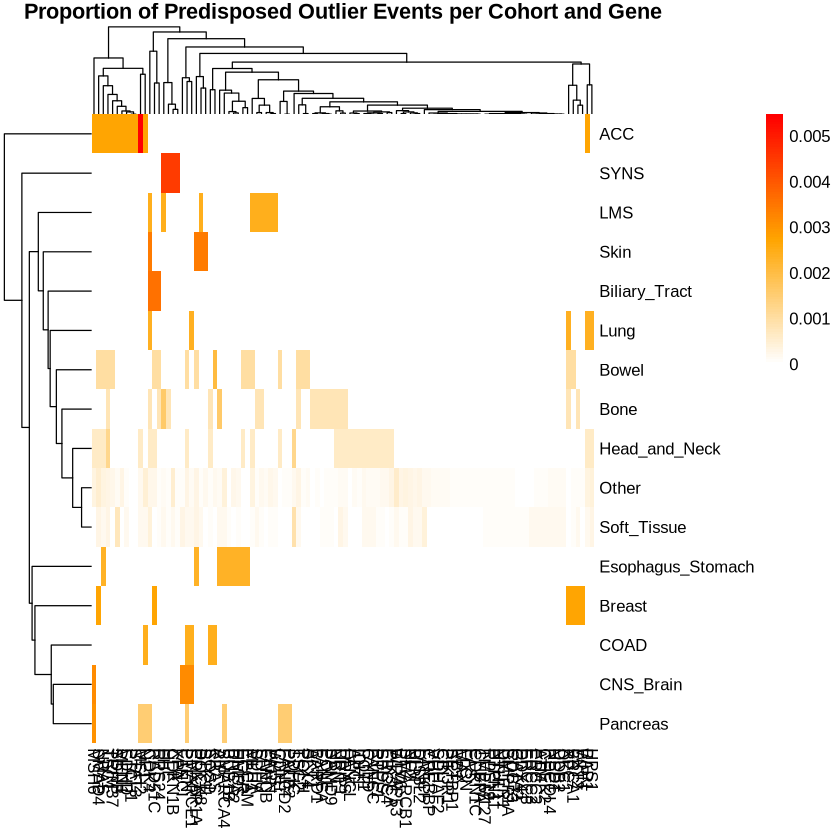

In [47]:


source("~/Scripts/utils/load_gtf_cgc_dresden.R")

or_res_all <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_outliers.tsv")
fr_res_all_genes <- fread( "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_results.tsv")

or_res_all[, predosposition_gene := FALSE]
or_res_all[hgncSymbol %in% dresden_list, predosposition_gene := TRUE]

cohort_props <- as.data.table(or_res_all %>%
  group_by(Diag) %>%
  summarise(proportion = mean(predosposition_gene, na.rm = TRUE)))

bar_plot <- ggplot(cohort_props, aes(y = Diag, x = proportion)) +
  geom_bar(stat = "identity", fill = "orange") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Proportion", title = "Proportion of Predisposed Outliers")



cohort_totals <- or_res_all %>%
  group_by(Diag) %>%
  summarise(total_outlier_genes = n(), .groups = "drop")

# Step 2: For each gene in dresden_list, count predisposed outlier occurrences per cohort (not distinct)
gene_details <- or_res_all %>%
  filter(hgncSymbol %in% dresden_list, predosposition_gene == TRUE) %>%
  group_by(Diag, hgncSymbol) %>%
  summarise(gene_predisposed_outlier_genes = sum(predosposition_gene == TRUE), .groups = "drop") %>%
  pivot_wider(names_from = hgncSymbol,
              values_from = gene_predisposed_outlier_genes,
              values_fill = 0)

# Step 3: Merge with cohort totals
cohort_with_genes <- left_join(cohort_totals, gene_details, by = "Diag")


# intermediate step: calculate enrichments
# dt is your original data.table
dt_long <- as.data.table(melt(cohort_with_genes, id.vars = c("Diag", "total_outlier_genes"), 
                variable.name = "Gene", value.name = "IsOutlier"))

results <- dt_long[, {
  a <- sum(IsOutlier == 1)   # Outliers for gene in this diag
  b <- sum(IsOutlier == 0)   # Non-outliers for gene in this diag
  
  # For all other diags
  other <- dt_long[Diag != .BY$Diag & Gene == .BY$Gene]
  c <- sum(other$IsOutlier == 1)
  d <- sum(other$IsOutlier == 0)
  
  test <- fisher.test(matrix(c(a, b, c, d), nrow = 2))
  
  list(Out_in_diag = a, Not_out_in_diag = b, Out_not_diag = c, Not_out_not_diag = d,
       OddsRatio = test$estimate,
       P = test$p.value)
}, by = .(Diag, Gene)]

results[, P_adj := p.adjust(P, method = "BH")]


# Step 4: Calculate proportions for each gene column (no prefixes)
gene_cols <- setdiff(colnames(cohort_with_genes), c("Diag", "total_outlier_genes"))
for (g in gene_cols) {
  cohort_with_genes[[g]] <- cohort_with_genes[[g]] / cohort_with_genes$total_outlier_genes
}

# Step 5: Prepare matrix for heatmap
heatmap_mat <- as.matrix(cohort_with_genes[, gene_cols])
rownames(heatmap_mat) <- cohort_with_genes$Diag

# Step 6: Custom color palette for better visibility
color_palette <- colorRampPalette(c("white", "orange", "red"))(100)

# Step 7: Plot the heatmap
p2 <- pheatmap(heatmap_mat,
         color = color_palette,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         scale = "none",
         main = "Proportion of Predisposed Outlier Events per Cohort and Gene")

rownames(cohort_props) <- cohort_props$Diag
# cohort_props <- cohort_props[rownames(heatmap_mat), ]

# Define color mapping for the heatmap
col_fun = colorRamp2(c(0, max(heatmap_mat)), c("white", "red"))

# Make barplot annotation using anno_barplot
bar_anno <- rowAnnotation(
  " " = anno_barplot(
    cohort_props$proportion,
    gp = gpar(fill = "orange"),
    width = unit(2, "cm"),
    axis_param = list(direction = "reverse") # bars to the right
  )
)

png("./or_heatmap.png", width = 4000, height = 2000, res = 300)
# Plot heatmap + annotation
ht <- Heatmap(
  heatmap_mat,
name = "Proportion of predisposition\ngenes across outliers ",
  col = col_fun,
  right_annotation = bar_anno,
  cluster_rows = TRUE, # or FALSE for ordered Diag
  cluster_columns = TRUE,
  row_names_gp = gpar(fontsize = 8),        # Reduce row labels font size
  column_names_gp = gpar(fontsize = 8)     # Reduce column labels font size
)
    

draw(ht)
dev.off()

or_res_all_predosposition <- or_res_all[hgncSymbol %in% dresden_list]


or_res_all_predosposition[, expression_direction := "Underexpression"]
or_res_all_predosposition[zScore > 0, expression_direction := "Overexpression"]
table(or_res_all_predosposition$expression_direction)
table(or_res_all_predosposition$Diag)


or_res_all_predosposition_extended <- or_res_all[hgncSymbol %in% extended_dresden_list]
or_res_all_predosposition_extended[, expression_direction := "Underexpression"]
or_res_all_predosposition_extended[zScore > 0, expression_direction := "Overexpression"]
table(or_res_all_predosposition_extended$expression_direction)

#or_res_all_predosposition_extended





In [19]:
library(ggplot2)
fr_res_all_genes[, predosposition_gene := FALSE]
fr_res_all_genes[hgncSymbol %in% dresden_list, predosposition_gene := TRUE]

cohort_props <- as.data.table(fr_res_all_genes %>%
  group_by(Diag) %>%
  summarise(proportion = mean(predosposition_gene, na.rm = TRUE)))

bar_plot <- ggplot(cohort_props, aes(y = Diag, x = proportion)) +
  geom_bar(stat = "identity", fill = "orange") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Proportion", title = "Proportion of Predisposed Outliers")



cohort_totals <- fr_res_all_genes %>%
  group_by(Diag) %>%
  summarise(total_outlier_genes = n(), .groups = "drop")

# Step 2: For each gene in dresden_list, count predisposed outlier occurrences per cohort (not distinct)
gene_details <- fr_res_all_genes %>%
  filter(hgncSymbol %in% dresden_list, predosposition_gene == TRUE) %>%
  group_by(Diag, hgncSymbol) %>%
  summarise(gene_predisposed_outlier_genes = sum(predosposition_gene == TRUE), .groups = "drop") %>%
  pivot_wider(names_from = hgncSymbol,
              values_from = gene_predisposed_outlier_genes,
              values_fill = 0)

# Step 3: Merge with cohort totals
cohort_with_genes <- left_join(cohort_totals, gene_details, by = "Diag")


# intermediate step: calculate enrichments
# dt is your original data.table
dt_long <- as.data.table(melt(cohort_with_genes, id.vars = c("Diag", "total_outlier_genes"), 
                variable.name = "Gene", value.name = "IsOutlier"))

results <- dt_long[, {
  a <- sum(IsOutlier == 1)   # Outliers for gene in this diag
  b <- sum(IsOutlier == 0)   # Non-outliers for gene in this diag
  
  # For all other diags
  other <- dt_long[Diag != .BY$Diag & Gene == .BY$Gene]
  c <- sum(other$IsOutlier == 1)
  d <- sum(other$IsOutlier == 0)

  test <- fisher.test(matrix(c(a, b, c, d), nrow = 2))
  
  list(Out_in_diag = a, Not_out_in_diag = b, Out_not_diag = c, Not_out_not_diag = d,
       OddsRatio = test$estimate,
       P = test$p.value)
}, by = .(Diag, Gene)]

results[, P_adj := p.adjust(P, method = "BH")]


# Step 4: Calculate proportions for each gene column (no prefixes)
gene_cols <- setdiff(colnames(cohort_with_genes), c("Diag", "total_outlier_genes"))
for (g in gene_cols) {
  cohort_with_genes[[g]] <- cohort_with_genes[[g]] / cohort_with_genes$total_outlier_genes
}

# Step 5: Prepare matrix for heatmap
heatmap_mat <- as.matrix(cohort_with_genes[, gene_cols])
rownames(heatmap_mat) <- cohort_with_genes$Diag

# Step 6: Custom color palette for better visibility
color_palette <- colorRampPalette(c("white", "orange", "red"))(100)

# Step 7: Plot the heatmap
p2 <- pheatmap(heatmap_mat,
         color = color_palette,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         scale = "none",
         main = "Proportion of Predisposed Outlier Events per Cohort and Gene")

rownames(cohort_props) <- cohort_props$Diag
# cohort_props <- cohort_props[rownames(heatmap_mat), ]

# Define color mapping for the heatmap
col_fun = colorRamp2(c(0, max(heatmap_mat)), c("white", "red"))

# Make barplot annotation using anno_barplot
bar_anno <- rowAnnotation(
  " " = anno_barplot(
    cohort_props$proportion,
    gp = gpar(fill = "orange"),
    width = unit(2, "cm"),
    axis_param = list(direction = "reverse") # bars to the right
  )
)

png("heatmap.png", width = 4000, height = 2000, res = 300)
# Plot heatmap + annotation
ht <- Heatmap(
  heatmap_mat,
  name = "Proportion of predisposition\ngenes across outliers ",
  col = col_fun,
  right_annotation = bar_anno,
  cluster_rows = TRUE, # or FALSE for ordered Diag
  cluster_columns = TRUE,
  row_names_gp = gpar(fontsize = 8),        # Reduce row labels font size
  column_names_gp = gpar(fontsize = 8)     # Reduce column labels font size
)

draw(ht)
dev.off()


fr_res_all_predosposition <- fr_res_all_genes[hgncSymbol %in% dresden_list]
table(fr_res_all_predosposition$Diag)


fr_res_all_predosposition_extended <- fr_res_all_genes[hgncSymbol %in% extended_dresden_list]

#table(fr_res_all_predosposition_extended$Diag)

ERROR: Error: object 'fr_res_all_genes' not found


In [16]:
png("heatmap.png", width = 4500, height = 2000, res = 300)
# Plot heatmap + annotation
ht <- Heatmap(
  heatmap_mat,
  name = "Proportion of outlier predisposition\ngenes across outliers ",
  col = col_fun,
  right_annotation = bar_anno,
  cluster_rows = TRUE, # or FALSE for ordered Diag
  cluster_columns = TRUE,
  row_names_gp = gpar(fontsize = 8),        # Reduce row labels font size
  column_names_gp = gpar(fontsize = 8)     # Reduce column labels font size
)

draw(ht)
dev.off()


pdf 
  2

In [58]:

source("~/Scripts/ProteinExpression/load_pr_data.R")

# load gtf, and cancer genes
source("~/Scripts/utils/load_gtf_cgc_dresden.R")
source("~/Scripts/utils/theme.R")

create_enrichments <- function(res_dt, expression_direction, exp_gene){
  
  if (expression_direction == "underexpression"){
      cgc_dt <- cgc_tsg
  } else if (expression_direction == "overexpression" || expression_direction == "activation"){
      cgc_dt <- cgc_oncogene
  } else if (expression_direction == "under_predisposed"){ # predisposiotion genes
      cgc_dt <- dresden_dt_tsg
  } else if (expression_direction == "over_predisposed"){
      cgc_dt <- dresden_dt_oncogene
  } else if (expression_direction == "predisposed"){
      cgc_dt <- dresden_dt    
  } else if (expression_direction == "activation_predisposed"){
      cgc_dt <- dresden_dt_oncogene
  }
  #print("number of genes in interested group:")
  print(nrow(cgc_dt))
  
  #' OUTRIDER number of input genes & samples
  # dim(ods)
  #' OUTRIDER number of genes detected with outliers
  res_dt[, unique(geneID)] %>% length()
  
  #' OUTRIDER number of underexpression outliers per sample - median
  or_dn_samp_freq <- data.table(sampleID = unique(res_dt$sampleID))
  #or_dn_samp_freq <- data.table(sampleID = unique(ods$sampleID))
  or_dn_samp_freq <- merge(or_dn_samp_freq, res_dt[, .N, by='sampleID'], all=TRUE)
  or_dn_samp_freq[is.na(N), N := 0]
  or_dn_samp_freq[, sample_rank := rank(N, ties.method = 'random')]
  median(or_dn_samp_freq[, N])
  
  
  
  
  
  # all 
  if (expression_direction == "underexpression" || expression_direction == "under_predisposed" && "zScore" %in% colnames(res_dt)){
    or_dn <- res_dt[zScore < 0, ]
  } else if (expression_direction == "overexpression" || expression_direction == "over_predisposed"){
    or_dn <- res_dt[zScore > 0, ]
  } else{
    or_dn <- res_dt
  }

  print(nrow(or_dn))
  
  # or_dn <- or_dn %>%
  #   mutate(geneID_short = sub("\\..*", "", geneID))
  # 
  
  
  
  
  
  
  or_dn_freq <- or_dn[, .N, by='geneID']
  or_dn_gene <- or_dn_freq[, geneID]
  or_dn_gene_0 <- exp_gene[!exp_gene %in% or_dn_freq[, geneID]]
  or_dn_gene_1 <- or_dn_freq[N>=1, geneID]
  or_dn_gene_2 <- or_dn_freq[N>=2, geneID]
  or_dn_gene_5 <- or_dn_freq[N>=5, geneID]
  
  
  #' enrichment overall
  fisher_test(or_dn_gene, exp_gene, cgc_dt[, geneID])$estimate
  fisher_test(or_dn_gene, exp_gene, cgc_dt[, geneID])$p.value
  
  
  
  or_dn_all_en <- data.table(
    category = c(
      "0", "\u22651", "\u22652", "\u22655"
    ),
    odds_ratio = c(
      fisher_test(or_dn_gene_0, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_gene_1, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_gene_2, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_gene_5, exp_gene, cgc_dt[, geneID])$estimate
    ),
    ci_min = c(
      fisher_test(or_dn_gene_0, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_gene_1, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_gene_2, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_gene_5, exp_gene, cgc_dt[, geneID])$conf.int[1]
    ),
    ci_max = c(
      fisher_test(or_dn_gene_0, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_gene_1, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_gene_2, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_gene_5, exp_gene, cgc_dt[, geneID])$conf.int[2]
    ),
    p_val = c(
      fisher_test(or_dn_gene_0, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_gene_1, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_gene_2, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_gene_5, exp_gene, cgc_dt[, geneID])$p.value
    ),
    total = c(
      length(or_dn_gene_0),
      length(or_dn_gene_1),
      length(or_dn_gene_2),
      length(or_dn_gene_5)
    ))
  
  or_dn_all_en[, p_val.signif := lapply(p_val, add_significance)]
  or_dn_all_en[, category := factor(category, levels = c("0", "\u22651", "\u22652", "\u22655"))]
  or_dn_all_en[, cutoff := 'All']
  
  # top 3
  or_dn <- merge(or_dn, or_dn[, .(geneID, rank(padjust)), by='sampleID'], 
                 by = c('geneID', 'sampleID'))
  setnames(or_dn, 'V2', 'padjustRankInSample')
  or_dn_top3 <- or_dn[padjustRankInSample <= 3, ]
  or_dn_top3_freq <- or_dn_top3[, .N, by='geneID']
  or_dn_top3_gene_0 <- exp_gene[!exp_gene %in% or_dn_top3_freq[, geneID]]
  or_dn_top3_gene_1 <- or_dn_top3_freq[N>=1, geneID]
  or_dn_top3_gene_2 <- or_dn_top3_freq[N>=2, geneID]
  or_dn_top3_gene_5 <- or_dn_top3_freq[N>=5, geneID]
  
  or_dn_top3_en <- data.table(
    category = c(
      "0", "\u22651", "\u22652", "\u22655"
    ),
    odds_ratio = c(
      fisher_test(or_dn_top3_gene_0, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_top3_gene_1, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_top3_gene_2, exp_gene, cgc_dt[, geneID])$estimate,
      fisher_test(or_dn_top3_gene_5, exp_gene, cgc_dt[, geneID])$estimate
    ),
    ci_min = c(
      fisher_test(or_dn_top3_gene_0, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_top3_gene_1, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_top3_gene_2, exp_gene, cgc_dt[, geneID])$conf.int[1],
      fisher_test(or_dn_top3_gene_5, exp_gene, cgc_dt[, geneID])$conf.int[1]
    ),
    ci_max = c(
      fisher_test(or_dn_top3_gene_0, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_top3_gene_1, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_top3_gene_2, exp_gene, cgc_dt[, geneID])$conf.int[2],
      fisher_test(or_dn_top3_gene_5, exp_gene, cgc_dt[, geneID])$conf.int[2]
    ),
    p_val = c(
      fisher_test(or_dn_top3_gene_0, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_top3_gene_1, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_top3_gene_2, exp_gene, cgc_dt[, geneID])$p.value,
      fisher_test(or_dn_top3_gene_5, exp_gene, cgc_dt[, geneID])$p.value
    ),
    total = c(
      length(or_dn_top3_gene_0),
      length(or_dn_top3_gene_1),
      length(or_dn_top3_gene_2),
      length(or_dn_top3_gene_5)
    ))
  
  or_dn_top3_en[, p_val.signif := lapply(p_val, add_significance)]
  or_dn_top3_en[, category := factor(category, levels = c("0", "\u22651", "\u22652", "\u22655"))]
  or_dn_top3_en[, cutoff := 'At most three']
  
  or_dn_en <- rbind(or_dn_all_en, or_dn_top3_en)
  or_dn_en[, total_label := paste0(round(total/1000, digits=1), 'k')]
  or_dn_en[total < 1000, total_label := as.character(total)]
  or_dn_en[category=='0', total_pos := 1]
  or_dn_en[category=='\u22651', total_pos := 2]
  or_dn_en[category=='\u22652', total_pos := 3]
  or_dn_en[category=="\u22655", total_pos := 4]
  or_dn_en[cutoff=='All', total_pos := total_pos-0.15]
  or_dn_en[cutoff=='At most three', total_pos := total_pos+0.15]
  
  
  return (or_dn_en)
}

fisher_test <- function(test_gene, all_gene, test_list) {

  non_test_gene <- all_gene[!all_gene %in% test_gene]
                                                            
  contingency_df <- data.frame(
    "test[B_gene" = c(sum(test_gene %in% test_list), 
                    sum(!test_gene %in% test_list)),
    "non_test_gene" = c(sum(non_test_gene %in% test_list), 
                        sum(!non_test_gene %in% test_list)),
    row.names = c("leu", "non_leu"), stringsAsFactors = FALSE
  )
  
  fisher.test(contingency_df)
}

add_significance <- function(p) {
  # Define significance levels
  if (p <= 0.0001) {
    return("****")
  } else if (p <= 0.001) {
    return("***")
  } else if (p <= 0.01) {
    return("**")
  } else if (p <= 0.05) {
    return("*")
  }
   else {
    return("ns")
  }
}












In [49]:

exp_gene_fr <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/datasets/savedObjects/aggregated_expressed_genes.tsv")
#fr_res_junc <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/aggregated_fraser_res_junc.tsv")

In [53]:
fr_res_gene <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers.tsv")
fr_res_gene <- fr_res_gene[padjust <= 0.05]
fr_res_gene <- fr_res_gene[deltaPsi >= 0.3]
fr_res_gene = merge(fr_res_gene, gene_annot_dt[, c("gene_name", "gene_id")], by.x="hgncSymbol", by.y="gene_name")
setnames(fr_res_gene, "gene_id", "geneID")

In [63]:
fr_en

category,odds_ratio,ci_min,ci_max,p_val,total,p_val.signif,cutoff,total_label,total_pos
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>,<chr>,<dbl>
0,0.08700454,0.03090350,0.1986813,5.141667e-15,11961,****,All,12k,0.85
1,0.85231962,0.33085359,1.8480798,8.528246e-01,2515,ns,All,2.5k,1.85
2-4,1.08444294,0.57379316,1.9245898,7.684886e-01,4443,ns,All,4.4k,2.85
≥5,5.09955461,3.15948319,8.4142238,6.054597e-13,7293,****,All,7.3k,3.85
0,0.23963367,0.14954071,0.3894172,1.000155e-08,21572,****,At most three,21.6k,1.15
1,1.51927481,0.72429417,2.8933272,1.829017e-01,2351,ns,At most three,2.4k,2.15
2-4,8.64602462,4.91412588,14.6221263,1.199992e-11,942,****,At most three,942,3.15
≥5,1.20926697,0.03012264,6.9957608,5.661007e-01,258,ns,At most three,258,4.15


[1] 86
[1] 100009


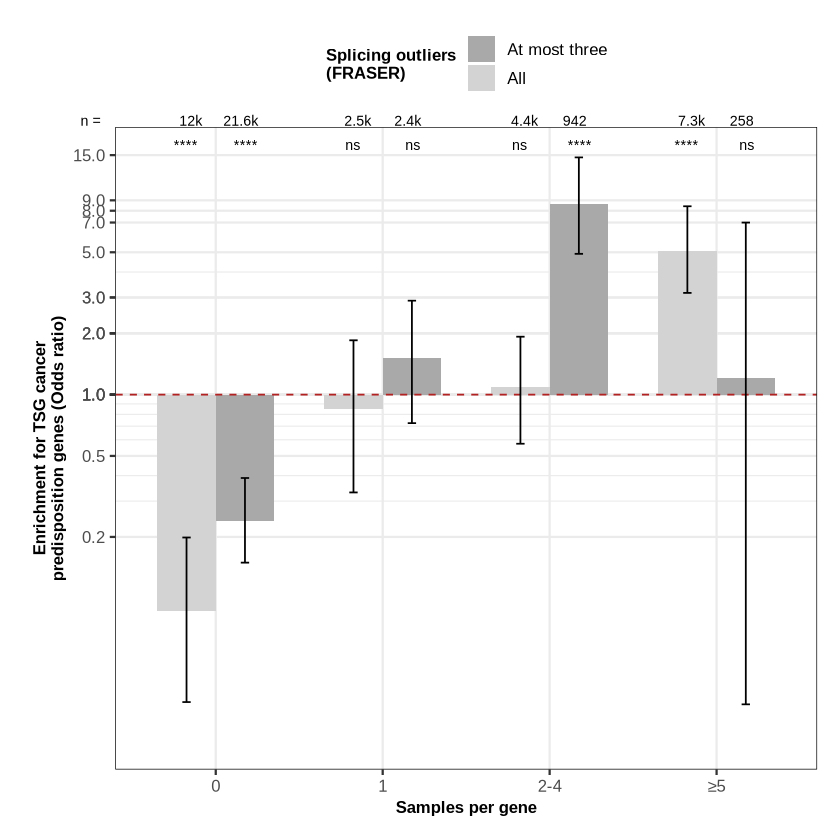

In [68]:
fr_en <- create_enrichments(fr_res_gene, expression_direction="under_predisposed", exp_gene_fr$geneID)


signif_height <- max(fr_en$ci_max) 

total_height <- max(fr_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, round(fr_en$odds_ratio), round(fr_en$ci_max))

p_a_raw <- ggplot(fr_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = fr_en[cutoff=='All'], aes(y=15, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = fr_en[cutoff=='At most three'], aes(y=15, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=fr_en[, total_pos], y=total_height*1.5, label=fr_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(fr_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for TSG cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Splicing outliers\n(FRASER)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a


In [13]:
res_dir <- "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/"
or_res_files <- list.dirs(res_dir, full.names = TRUE, recursive = FALSE)


#### OUTRIDER ####

or_res_all <- fread(paste0(res_dir, "aggregated_or_res_all.tsv"))
rna_exp_gene <- unique(or_res_all$geneID)
#rna_exp_gene <- sapply(rna_exp_gene, function(x){strsplit(x, "[.]")[[1]][1]})
length(rna_exp_gene)

or_res <- list()
for (drop_group in or_res_files){
  
  drop_group_name <- tail(unlist(strsplit(drop_group, "/")), 1)
  print(drop_group_name)
  if (drop_group_name == "Unstranded_data"){
    next
  }
  or_res_cohort <- fread(paste0(drop_group, "/OUTRIDER_results.tsv"))
  or_res <- rbind(or_res, or_res_cohort)
}

[1] 22946

[1] "ACC"
[1] "Biliary_Tract"
[1] "Bone"
[1] "Bowel"
[1] "Breast"
[1] "CNS_Brain"
[1] "COAD"
[1] "Esophagus_Stomach"
[1] "Head_and_Neck"
[1] "LMS"
[1] "Lung"
[1] "Other"
[1] "Pancreas"
[1] "Skin"
[1] "Soft_Tissue"
[1] "SYNS"
[1] "Unstranded_data"


In [5]:

#py_or_res <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/protrider_summary.csv")
py_or_res <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_expression_outliers.tsv")

#py_or_res <- left_join(py_or_res,rna_sa[, c("pid", "Oncotree Code", "SEX", "ICD10 Code", "TISSUE", "Tumorzellgehalt (Bioinformatik)")], by=c("sampleID" = "pid"))



In [10]:
py_or_res_exp_genes <- unique(py_or_res$geneID)
pr_coding_py_or_res_exp_genes = intersect(py_or_res_exp_genes, gene_annot_dt[gene_type== "protein_coding", gene_id])

py_or_res_aberrant <- py_or_res[padjust <= 0.05]
pr_coding_py_or_res_aberrant <- py_or_res[padjust <= 0.05]

summary <- pr_coding_py_or_res_aberrant[, .(total_outliers = .N), , by = sampleID]
threshold <- summary[, quantile(total_outliers, 0.95)]
samples_to_keep <- summary[total_outliers <= threshold, sampleID]
py_or_res_aberrant_95th <- pr_coding_py_or_res_aberrant[sampleID %in% samples_to_keep]


pr_coding_py_or_res_aberrant_95th <- py_or_res_aberrant_95th[padjust <= 0.05 & geneID %in% pr_coding_py_or_res_exp_genes]
pr_coding_py_or_res_aberrant <- py_or_res[padjust <= 0.05 & geneID %in% pr_coding_py_or_res_exp_genes]




[1] 32
[1] 28262


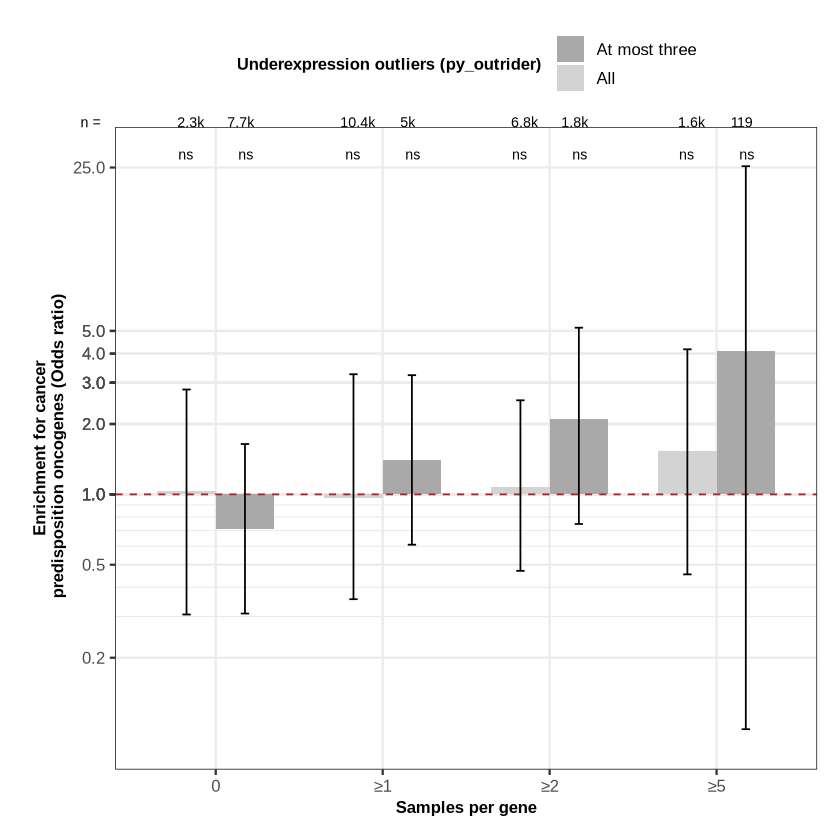

In [97]:

or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant[total_outliers <= 50,], expression_direction="over_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]



signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.4, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.4, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\n predisposition oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 17978


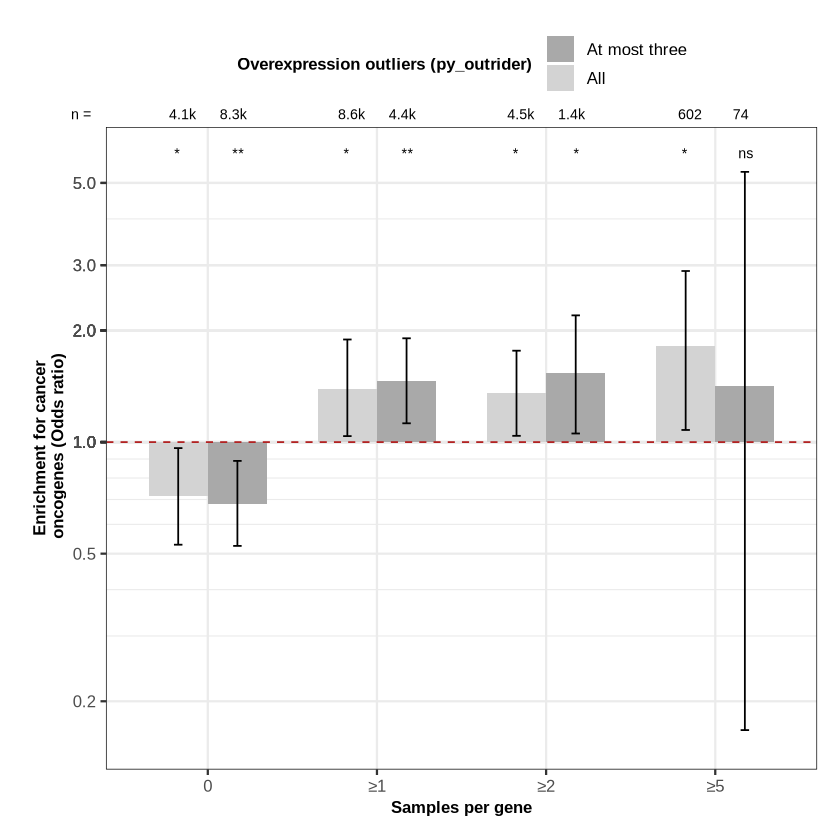

In [83]:

or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant[total_outliers <= 30,], expression_direction="overexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]



signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.3, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.3, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\n oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 17978


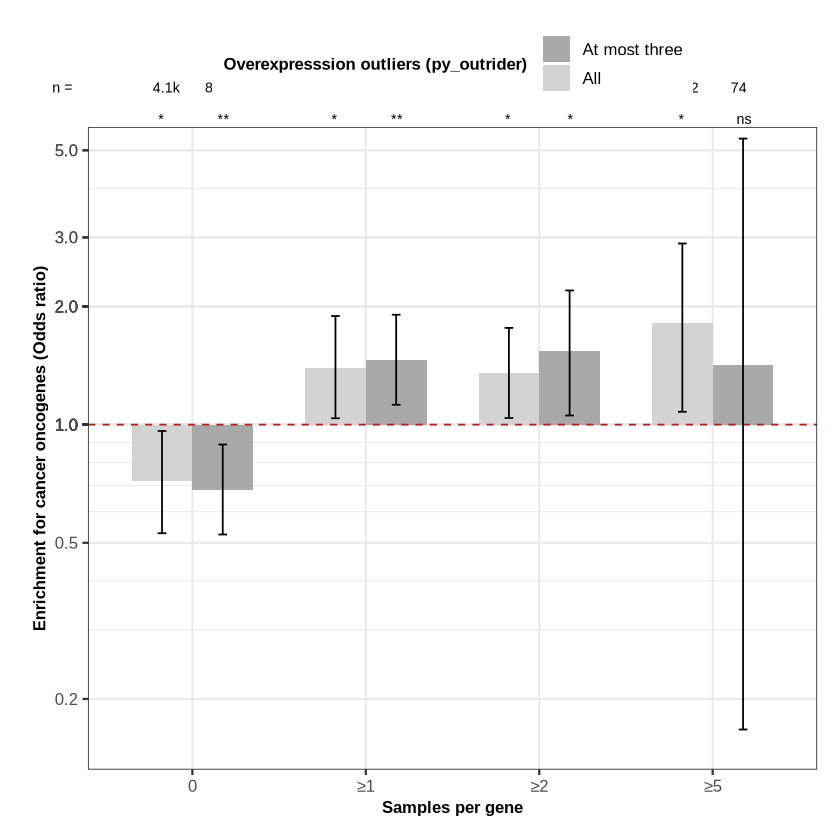

In [71]:

or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant[total_outliers <= 30,], expression_direction="overexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]



signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\ oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpresssion outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 86
[1] 23219


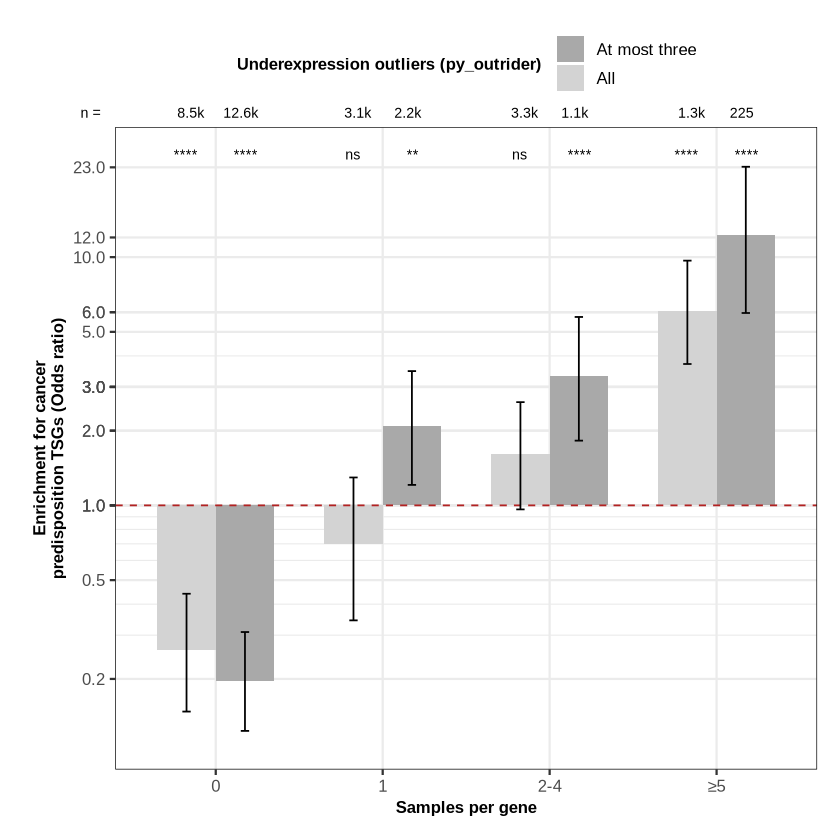

In [25]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant_95th, expression_direction="under_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition TSGs (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 86
[1] 28747


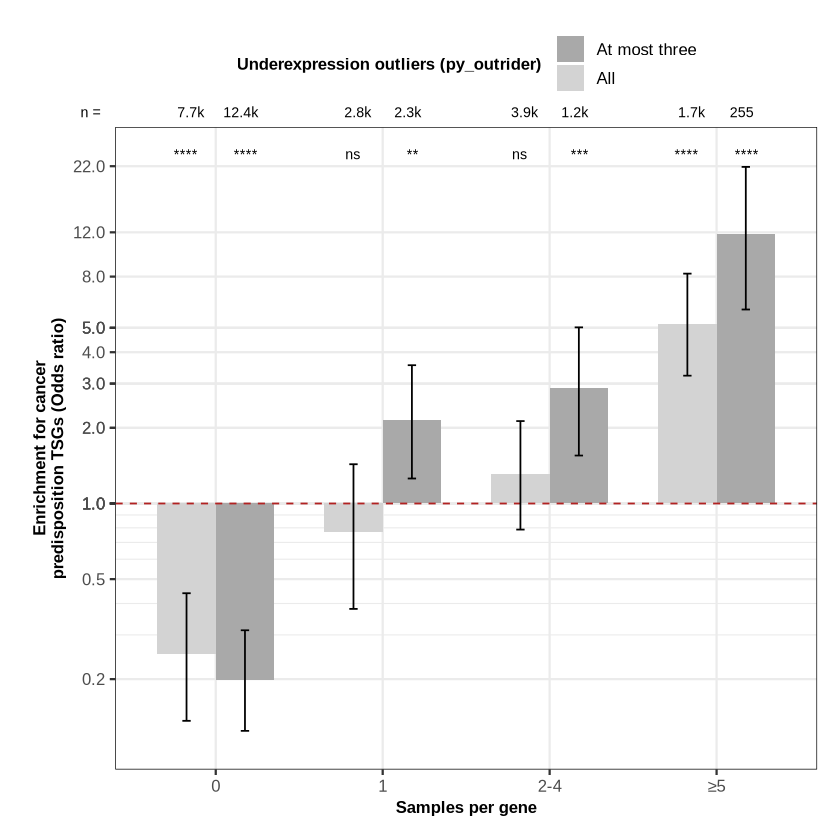

In [26]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant, expression_direction="under_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition TSGs (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 86
[1] 31336


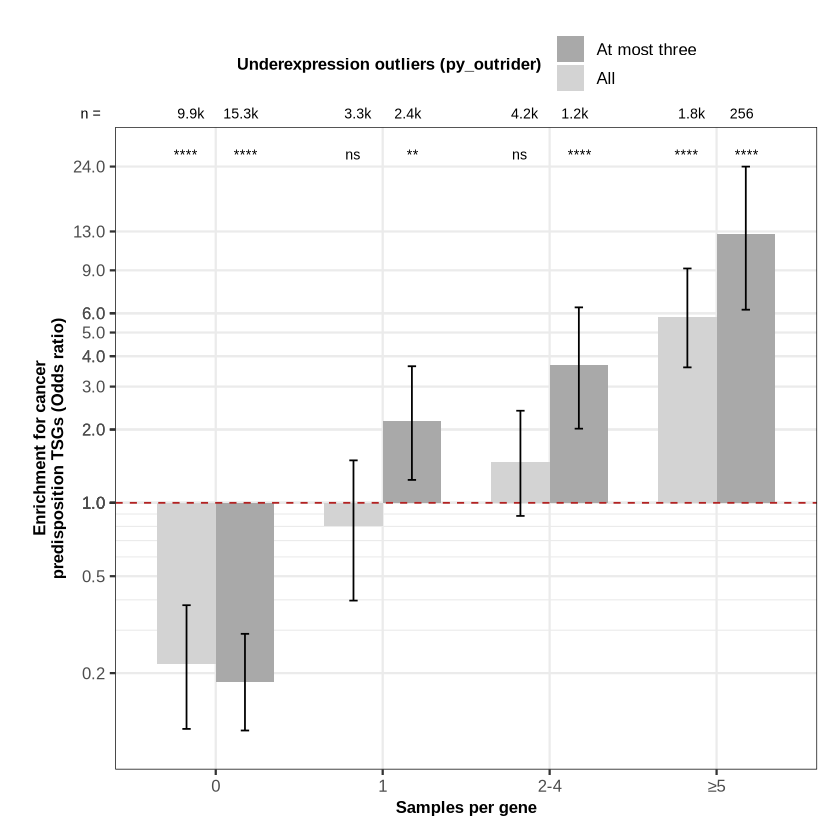

In [25]:
or_dn_en <- create_enrichments(py_or_res_aberrant, expression_direction="under_predisposed", exp_gene = py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition TSGs (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 28747


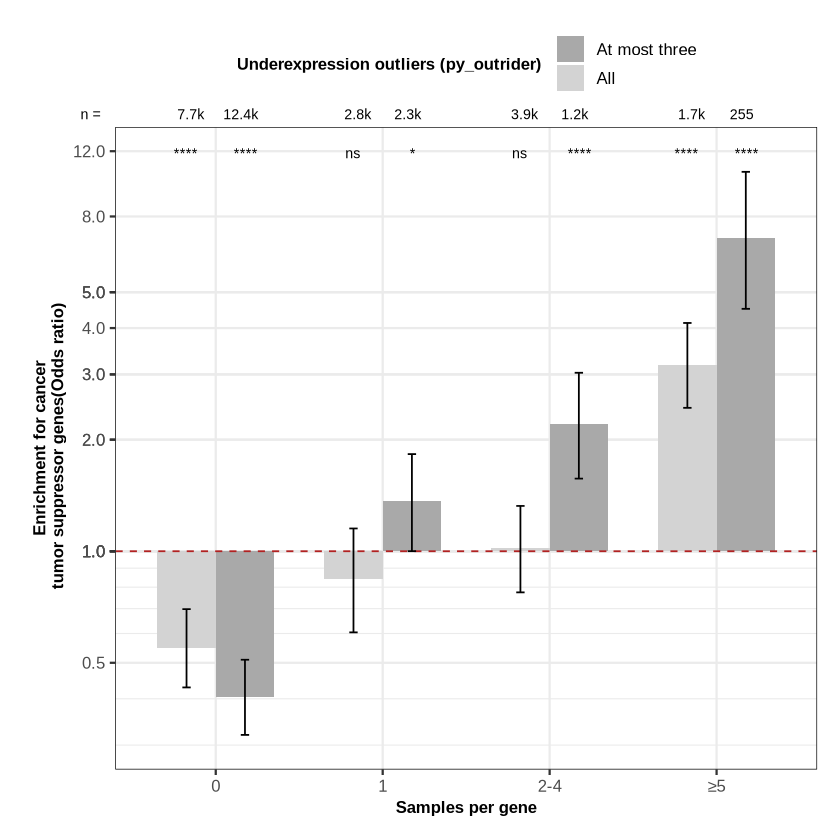

In [31]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant, expression_direction="underexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.3, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.3, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\n tumor suppressor genes(Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 86
[1] 23219


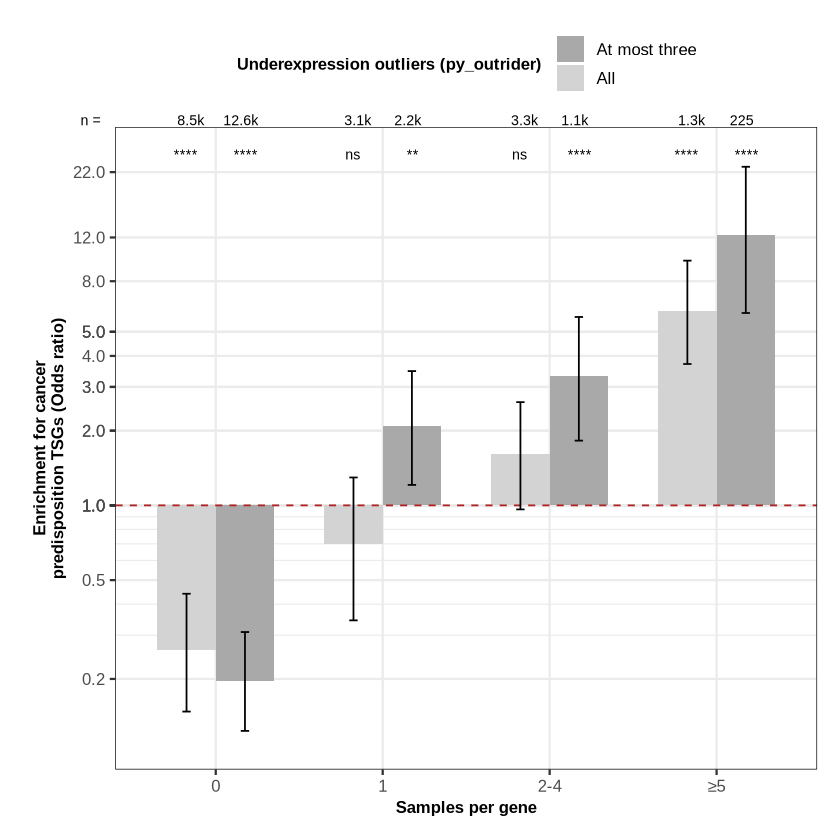

In [34]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant_95th, expression_direction="under_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.4, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.4, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition TSGs (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 23219


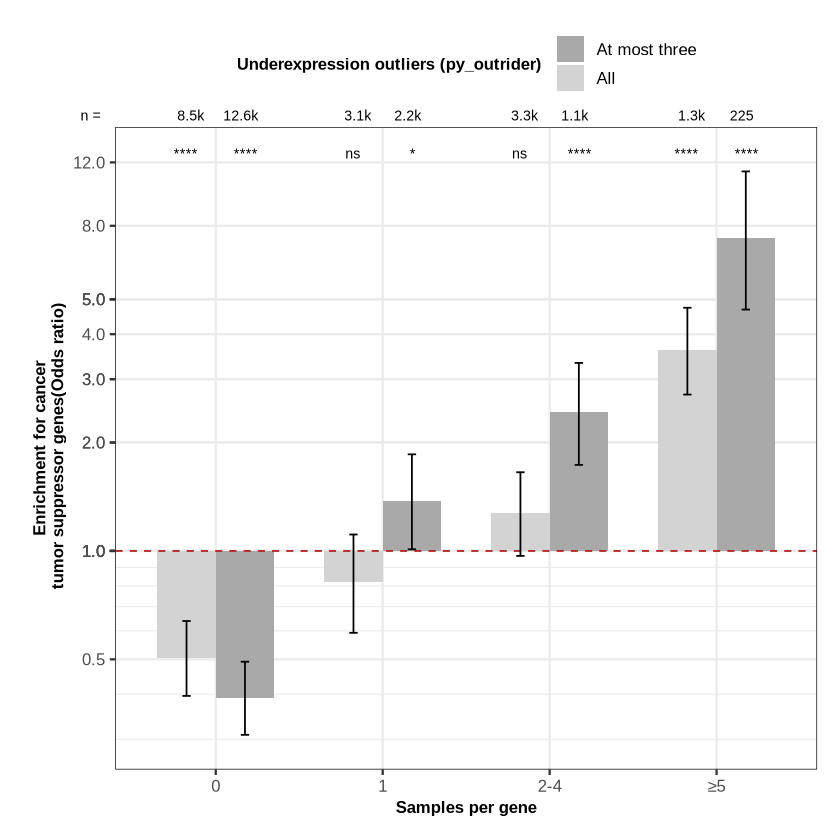

In [32]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant_95th, expression_direction="underexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.3, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.3, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\n tumor suppressor genes(Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 31537


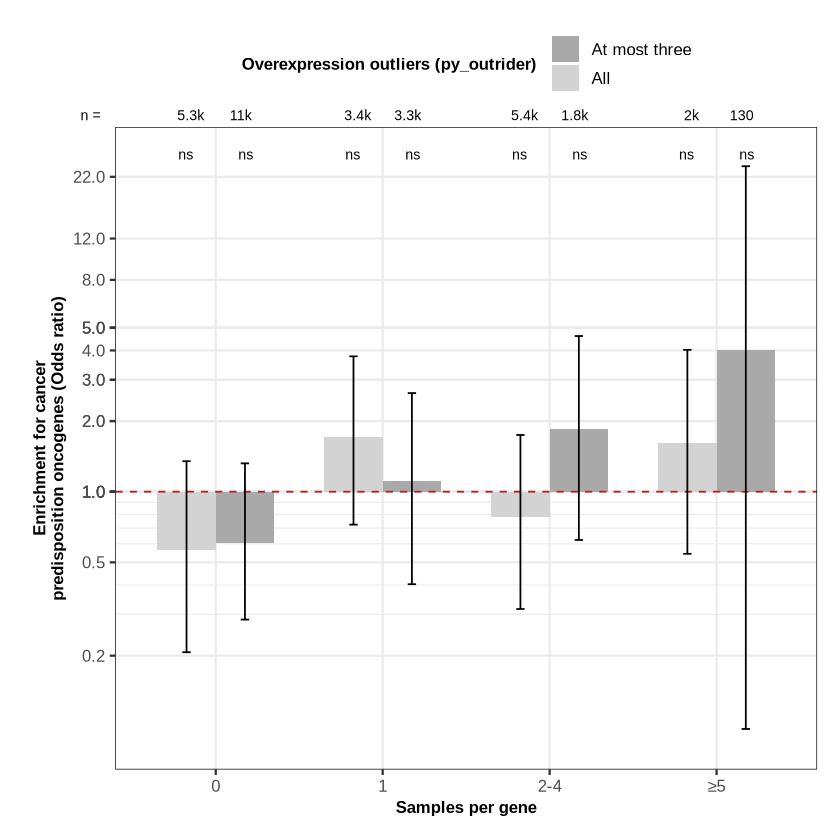

In [35]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant_95th, expression_direction="over_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 38548


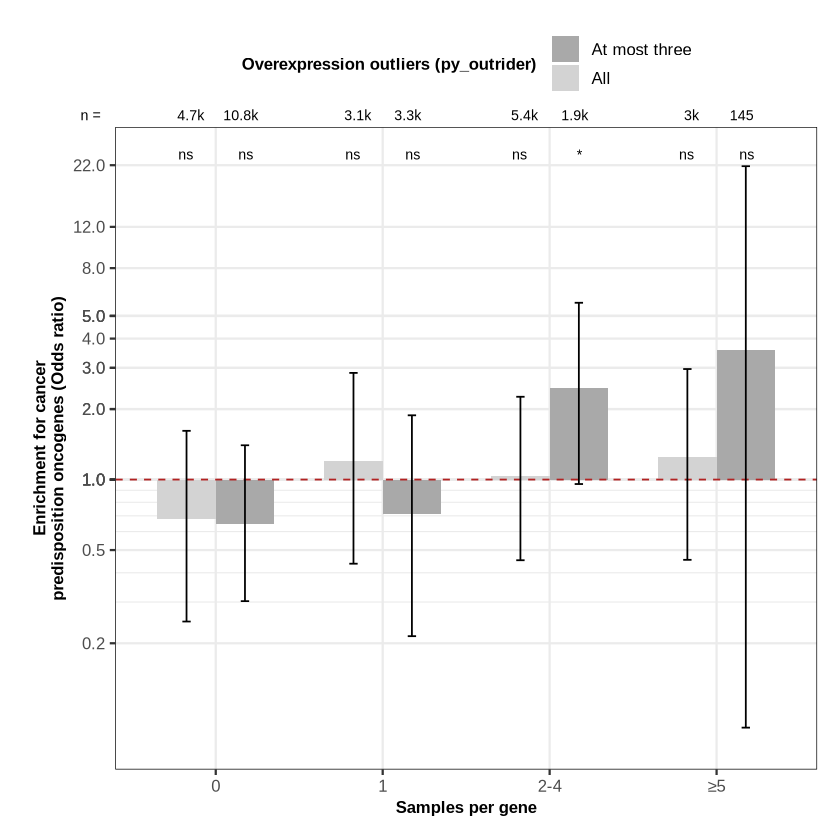

In [36]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant, expression_direction="over_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 38548


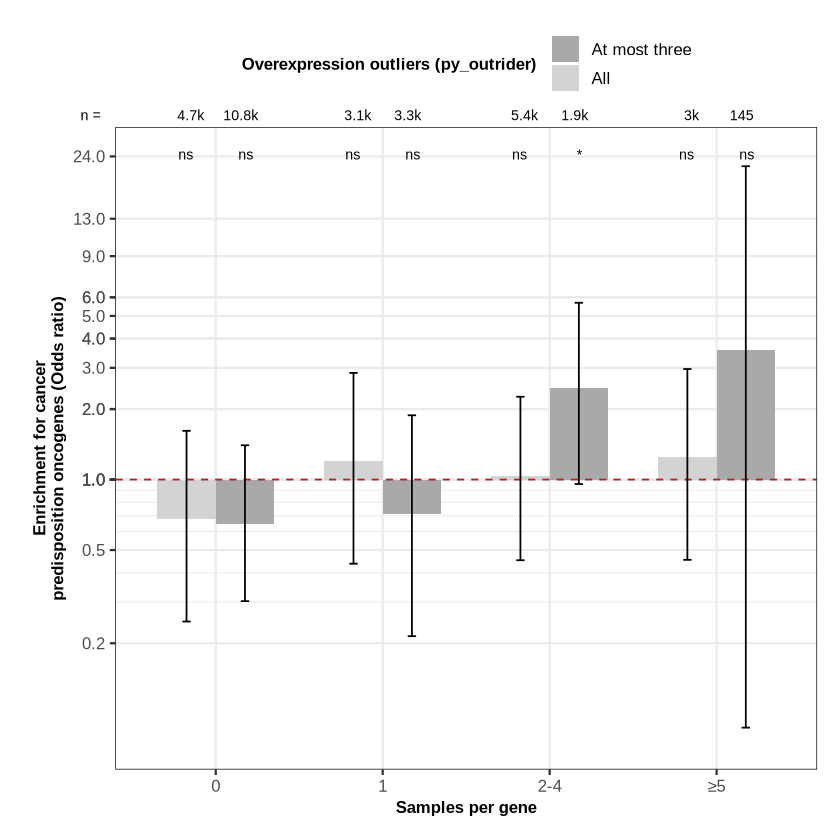

In [26]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant, expression_direction="over_predisposed", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\npredisposition oncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 38548


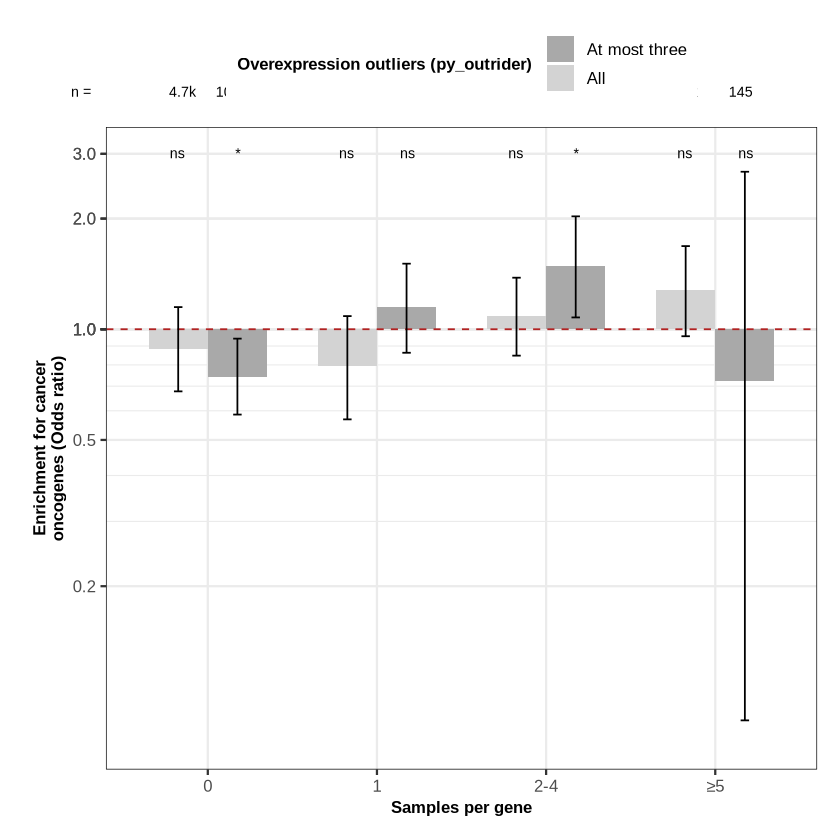

In [37]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant, expression_direction="overexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\noncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 321
[1] 31537


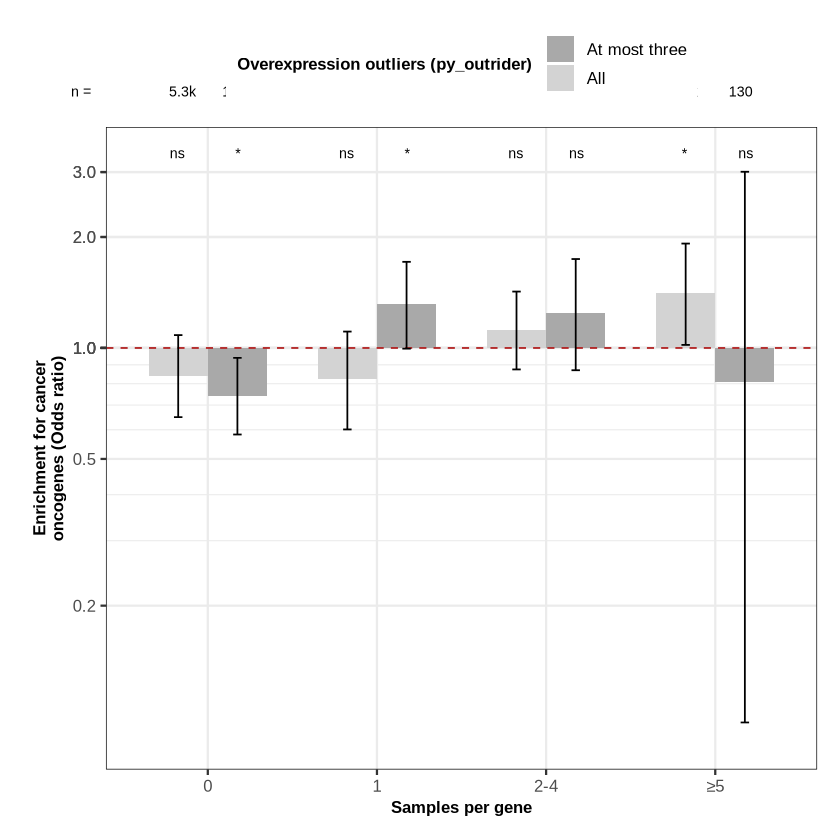

In [38]:
or_dn_en <- create_enrichments(pr_coding_py_or_res_aberrant_95th, expression_direction="overexpression", exp_gene = pr_coding_py_or_res_exp_genes)
or_dn_en[, method := "py_outrider"]

signif_height <- max(or_dn_en$ci_max) 
total_height <- max(or_dn_en$ci_max)*1.1

# y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_dn_en$odds_ratio), round(or_dn_en$ci_max))

p_a_raw <- ggplot(or_dn_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_dn_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_dn_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_dn_en[, total_pos], y=total_height*1.5, label=or_dn_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_dn_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for cancer\noncogenes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (py_outrider)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 86
[1] 16261


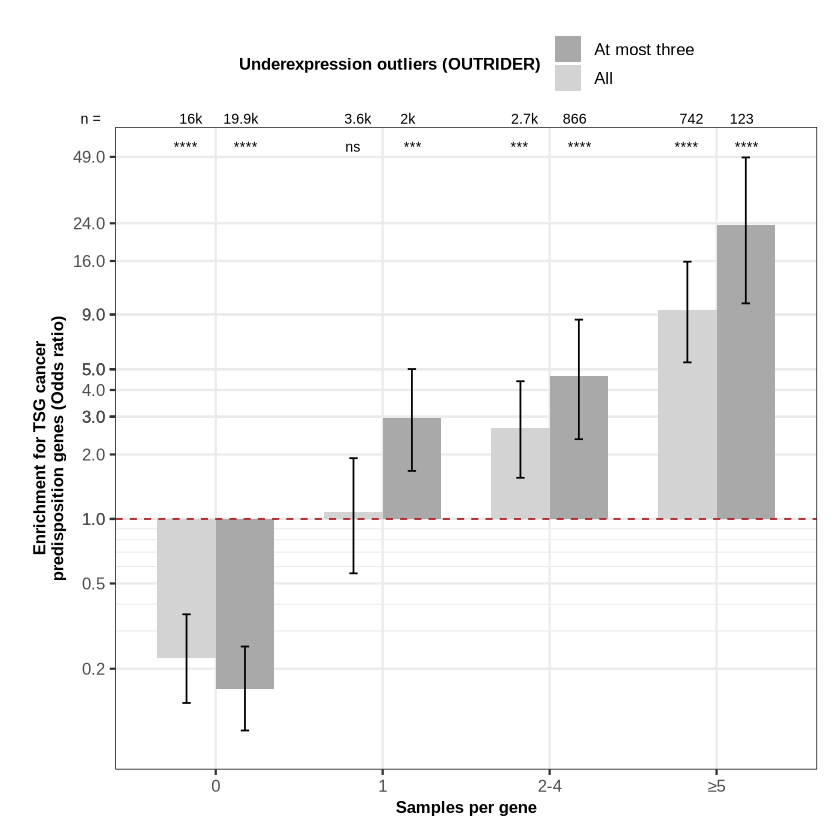

In [69]:
or_up_en <- create_enrichments(or_res, expression_direction="under_predisposed", exp_gene = rna_exp_gene)
or_up_en[, method := "OUTRIDER"]

signif_height <- max(or_up_en$ci_max) 
total_height <- max(or_up_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_up_en$odds_ratio), round(or_up_en$ci_max))

p_a_raw <- ggplot(or_up_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_up_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_up_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_up_en[, total_pos], y=total_height*1.5, label=or_up_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_up_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for TSG cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (OUTRIDER)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 19721


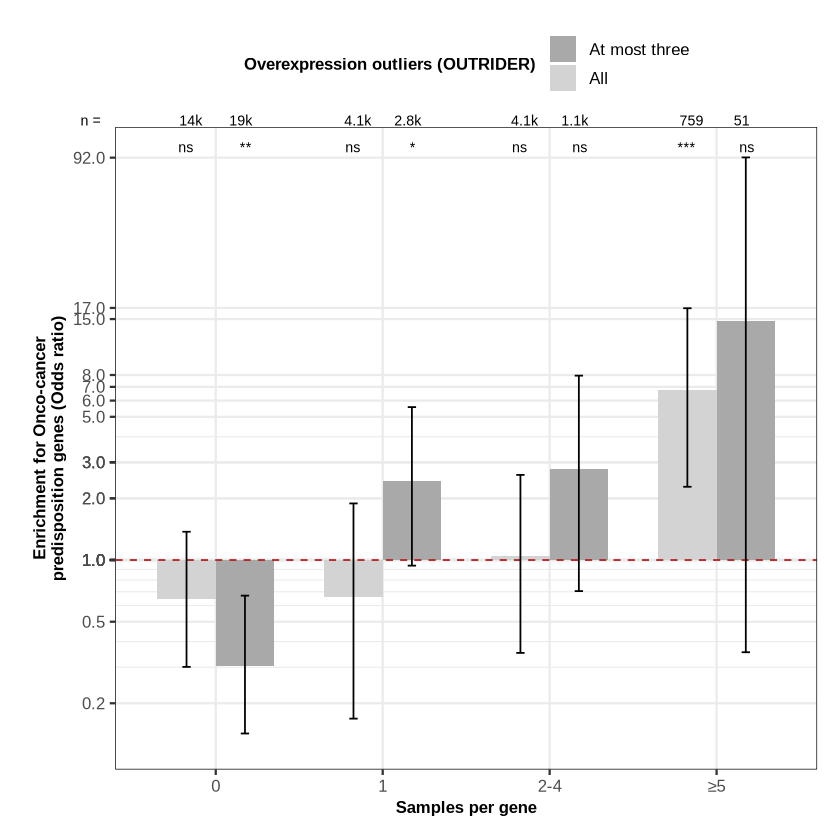

In [33]:
or_up_en <- create_enrichments(or_res, expression_direction="over_predisposed", exp_gene = rna_exp_gene)
or_up_en[, method := "OUTRIDER"]

signif_height <- max(or_up_en$ci_max) 
total_height <- max(or_up_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_up_en$odds_ratio), round(or_up_en$ci_max))

p_a_raw <- ggplot(or_up_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_up_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_up_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_up_en[, total_pos], y=total_height*1.5, label=or_up_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_up_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for Onco-cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (OUTRIDER)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

In [34]:
pr_output_name <- "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"
pr_res_all <-load_pr_data(paste0("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_", pr_output_name, "/protrider_summary.csv"))
pr_res_all[, geneID := gene_id]

exp_protein <- unique(pr_res_all$geneID)
protrider_samples <- unique(pr_res_all$sampleID)



pr_res <- pr_res_all[aberrant == T]



Warning message in `[.data.table`(pr_res, , `:=`("geneID", geneID_short)):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


[1] 86
[1] 2925


Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(coord_limits):
“NaNs produced”


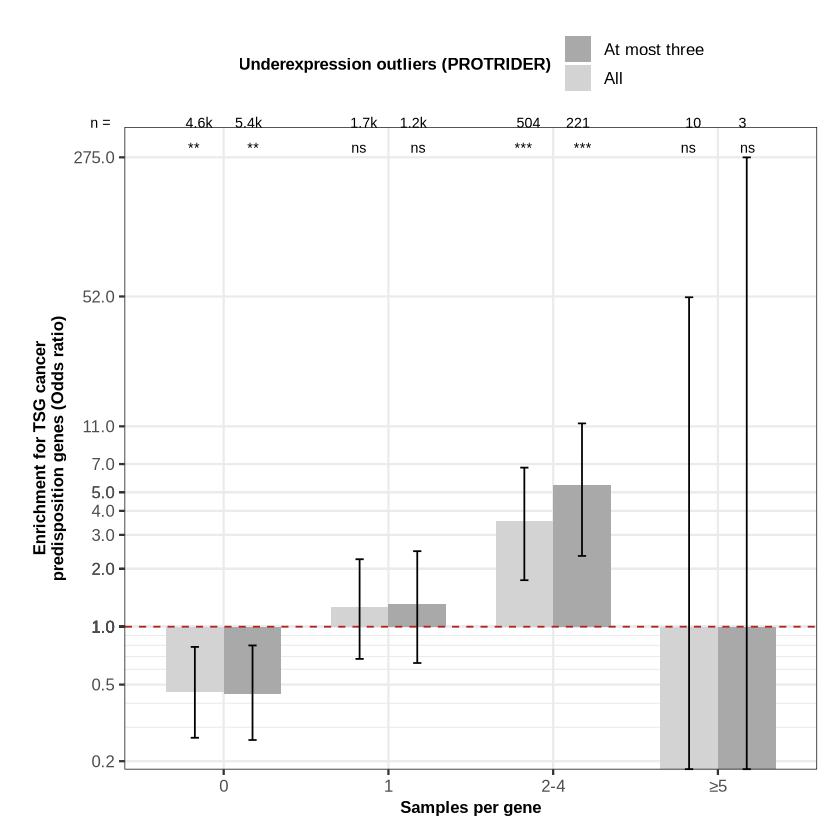

In [38]:
or_up_en <- create_enrichments(pr_res, expression_direction="under_predisposed", exp_gene = exp_protein)
or_up_en[, method := "PROTRIDER"]


signif_height <- max(or_up_en$ci_max) 
total_height <- max(or_up_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_up_en$odds_ratio), round(or_up_en$ci_max))

p_a_raw <- ggplot(or_up_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_up_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_up_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_up_en[, total_pos], y=total_height*1.5, label=or_up_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_up_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for TSG cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Underexpression outliers (PROTRIDER)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 1946


Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(coord_limits):
“NaNs produced”


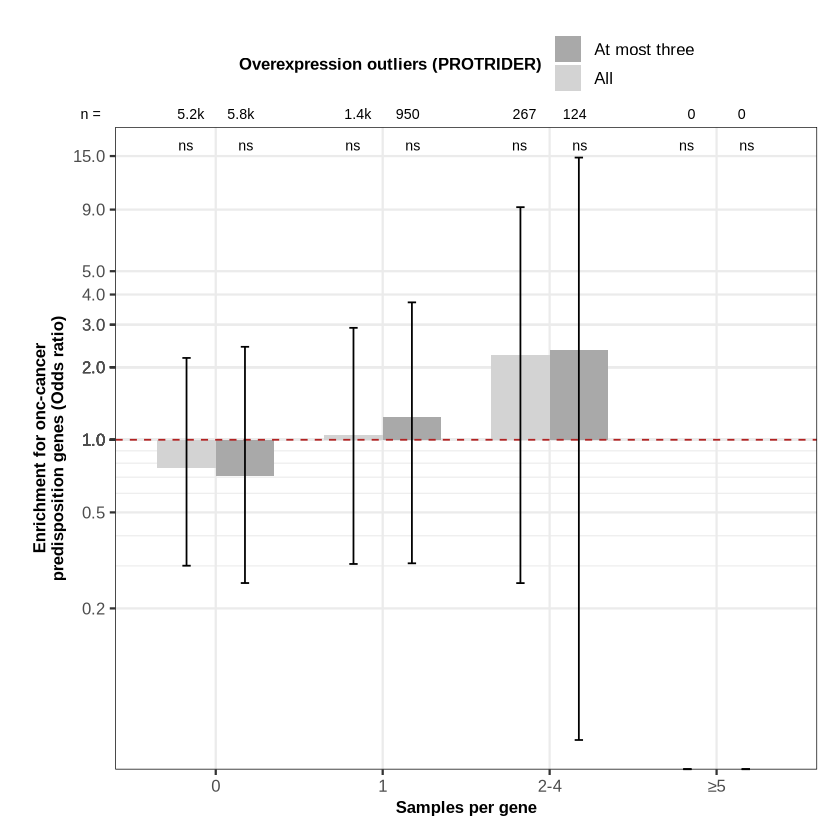

In [48]:
or_up_en <- create_enrichments(pr_res, expression_direction="over_predisposed", exp_gene = exp_protein)
or_up_en[, method := "PROTRIDER"]


or_up_en[ci_max == Inf, ci_max:=0]
or_up_en[total == 0, odds_ratio := 1]

signif_height <- max(or_up_en$ci_max) 
total_height <- max(or_up_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_up_en$odds_ratio), round(or_up_en$ci_max))

p_a_raw <- ggplot(or_up_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_up_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_up_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_up_en[, total_pos], y=total_height*1.5, label=or_up_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_up_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for onc-cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Overexpression outliers (PROTRIDER)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

[1] 32
[1] 22185


Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10(breaks = y_axis_breaks, minor_breaks = c(c(3:9)/10, :
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(coord_limits):
“NaNs produced”


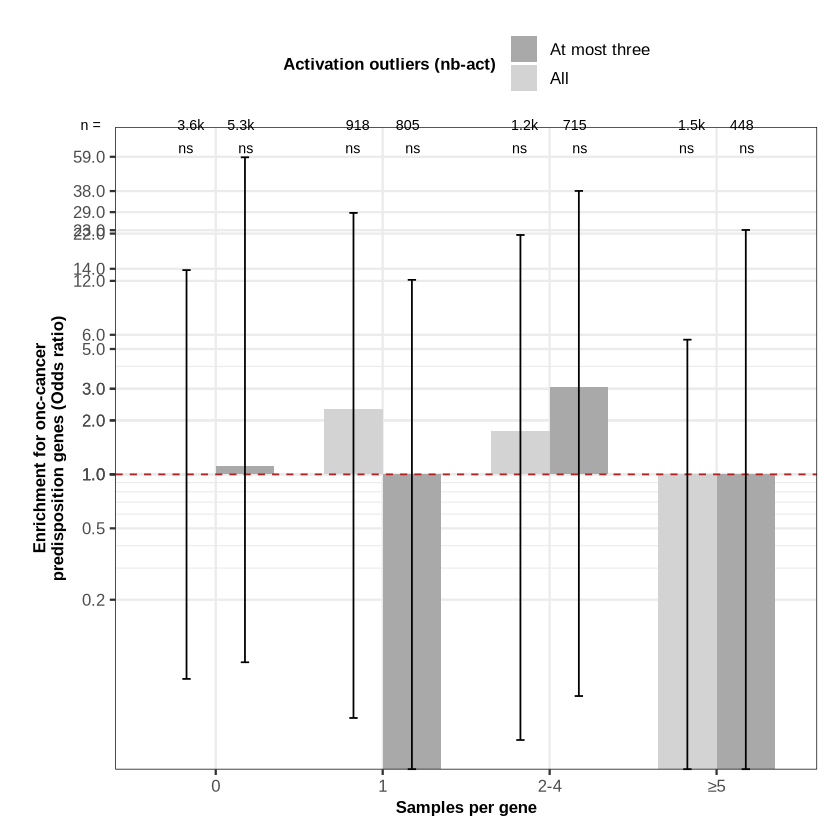

In [28]:
mu <- 5
theta <-100
activation_res <- fread(paste0("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/nb_act/activation_res_protein_coding_genes_sig_theta", theta, "_mu", mu, "_BH.tsv"))
rarely_expressed_genes <- fread(paste0("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/nb_act/rarely_expressed_protein_coding_genes_", theta, "_mu", mu, "_BH.tsv"), sep="\t")



or_up_en <- create_enrichments(activation_res, expression_direction="activation_predisposed", exp_gene = rarely_expressed_genes$rarely_expressed_genes)
or_up_en[ci_max == Inf, ci_max:=0]
or_up_en[total == 0, odds_ratio := 1]

signif_height <- max(or_up_en$ci_max) 
total_height <- max(or_up_en$ci_max)*1.01

y_axis_breaks <- c(0.2, 0.5, 1, 3, 5, round(or_up_en$odds_ratio), round(or_up_en$ci_max))

p_a_raw <- ggplot(or_up_en, aes(x=category, y=odds_ratio, fill = cutoff)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_text(data = or_up_en[cutoff=='All'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = -0.18, nudge_y = 0.05, size = 3) +
  geom_text(data = or_up_en[cutoff=='At most three'], aes(y=signif_height, label = p_val.signif), 
            stat = "identity", nudge_x = 0.18, nudge_y = 0.05, size = 3) +
  geom_hline(yintercept=1, linetype="dashed", color = "firebrick") +
  geom_errorbar(aes(ymin=ci_min, ymax=ci_max), 
                width=0.1, 
                position=position_dodge(width=0.7)) +   
  annotate("text", x=or_up_en[, total_pos], y=total_height*1.5, label=or_up_en[, total_label], size = 3) +
  annotate("text", x=0.25, y=total_height*1.5, label='n =', size = 3) +
  scale_y_log10(
    breaks = y_axis_breaks, 
    minor_breaks = c(c(3:9)/10, c(1:5))
  ) +
  coord_cartesian(ylim=c(min(or_up_en$ci_min) - 0.01, total_height), xlim=c(1, 4), clip="off")

# p_a_raw

p_a <- p_a_raw +
  xlab('Samples per gene') +
  ylab('Enrichment for onc-cancer\npredisposition genes (Odds ratio)') +
  scale_fill_manual(values=c('lightgrey', 'darkgrey')) +
  guides(fill=guide_legend('Activation outliers (nb-act)', 
                           title.position = "left", reverse = TRUE)) + 
  theme_vale + 
  theme(
    legend.position = "top",
    legend.direction = "vertical",
    #plot.margin = margin(67, 14, 14, 20, "points"), 
    panel.border = element_rect(colour = "black", fill=NA, linewidth=0.2)
  )
p_a

In [27]:
or_up_en

category,odds_ratio,ci_min,ci_max,p_val,total,p_val.signif,cutoff,total_label,total_pos
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>,<chr>,<dbl>
0,0.9983469,0.07235096,13.775856,1.0000000,3631,ns,All,3.6k,0.85
1,2.3025998,0.04381775,28.710589,0.4179399,918,ns,All,918,1.85
2-4,1.7343703,0.03301238,21.620854,0.5051545,1170,ns,All,1.2k,2.85
≥5,0.0000000,0.00000000,5.637919,0.5850112,1537,ns,All,1.5k,3.85
0,1.1165380,0.08958541,58.630507,1.0000000,5288,ns,At most three,5.3k,1.15
1,0.0000000,0.00000000,12.150757,1.0000000,805,ns,At most three,805,2.15
2-4,3.0513912,0.05806125,38.062070,0.3396895,715,ns,At most three,715,3.15
≥5,0.0000000,0.00000000,23.060328,1.0000000,448,ns,At most three,448,4.15


In [8]:
or_res <- readRDS("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/Other/ods.Rds")

In [9]:
gene_annot_dt[gene_name == "SMARCB1"]

seqnames,start,end,strand,gene_id,gene_name,gene_type,gene_status,gene_name_orig,geneID_short
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
22,24129150,24176703,+,ENSG00000099956.13,SMARCB1,protein_coding,KNOWN,SMARCB1,ENSG00000099956


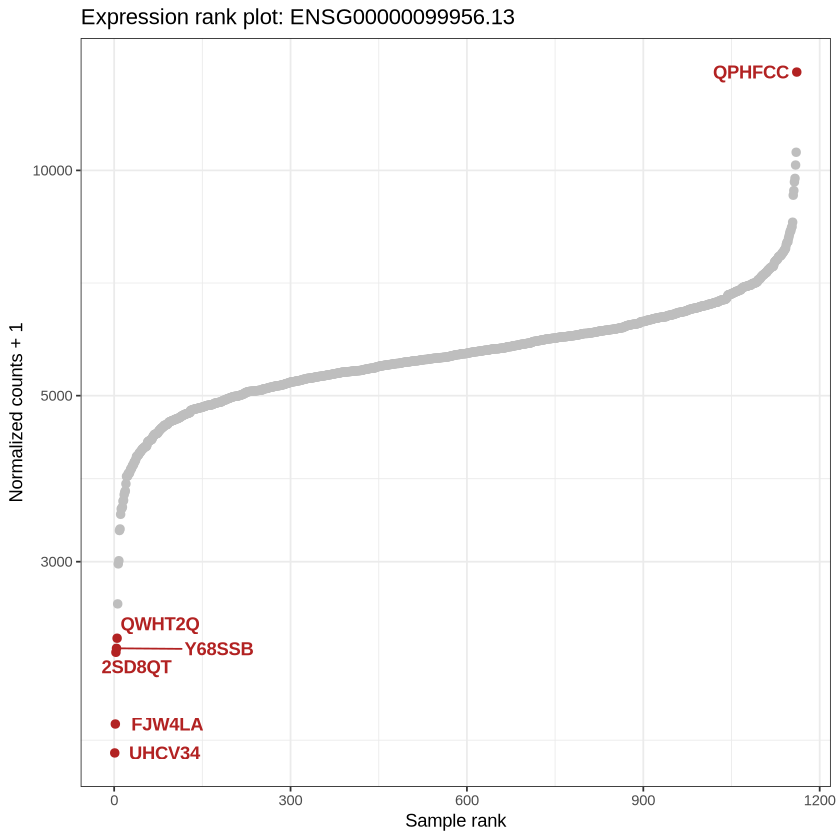

In [10]:
plotExpressionRank(or_res, "ENSG00000099956.13", basePlot=TRUE)